<a href="https://colab.research.google.com/github/michalis0/Business-Intelligence-and-Analytics/blob/master/Assignment/Assignment_2026_v1.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.graph_objs as go
import statistics

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, recall_score, precision_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

warnings.filterwarnings('ignore')
%matplotlib inline

<div>
<td>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/2/2b/Logo_Universit%C3%A9_de_Lausanne.svg/2000px-Logo_Universit%C3%A9_de_Lausanne.svg.png" style="padding-right:10px;width:240px;float:left"/></td>
<h2 style="white-space: nowrap">Business Intelligence and Analytics Personal Assignment</h2></td>
<hr style="clear:both">
<p style="font-size:0.85em; margin:2px; text-align:justify">
last updated 20.04.2026, v1

</div>

# Part 1: Venture Capital — Mapping the Next Unicorn

##  Context ✨

You have been hired as a **Junior Data Scientist at VenturAI**, a boutique venture capital firm that specializes in identifying high-potential startups before they become "Unicorns."

The Senior Partner has provided a snapshot of the global startup ecosystem: `investments_VC.csv`. This dataset contains historical information on thousands of companies across various markets and geographical locations.

**Your Mission:** Clean the data, explore the trends in startup funding, and build predictive or descriptive models to help the firm understand the key drivers of startup success.

---

Dataset Overview:

* Company Info: `name`, `market`, `status` (Operating, Acquired, Closed).

* Location: `country_code`, `state_code`, `region`, `city`.

* Timeline: `founded_at`, `first_funding_at`, `last_funding_at`.

* Financials: `funding_total_usd`, `funding_rounds`.

* Funding Types: `seed`, `venture`, `angel`, `round_A`, `round_B`, etc.

In [2]:
path = 'https://storage.googleapis.com/project_bia_unil/investments_VC.csv'
data_venture = pd.read_csv(path, encoding='latin1')
data_venture.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
data_venture.dtypes

,0
permalink,object
name,object
homepage_url,object
category_list,object
market,object
funding_total_usd,object
status,object
country_code,object
state_code,object
region,object


In [4]:
data_venture.shape

(54294, 39)

## 🧹 Exercise 1: Data Cleaning & Preprocessing

Data scientists spend nearly 80% of their time cleaning data! In this exercise, you must prepare the dataset for analysis. Raw datasets often come with inconsistencies that can bias your findings.

**Objective:** Build a clean, numeric-ready dataframe named `data_venture`.

**Tasks:**
*   **Normalization:** Strip redundant whitespace from strings and column headers.
*   **Data Type Correction:** Convert `funding_total_usd` into a clean float, removing any non-numeric distractions.
*   **Handling Missingness:** Categorize missing `market` and `status` values appropriately as 'N/A'.
*   **Filtering:** Focus on investment-ready entries (funding > 0).

The Venture Capital dataset contains information on thousands of startups, but it requires significant cleaning before it can be used for analysis. Your first task is to prepare the data by handling numeric conversions and missing values to ensure the funding data is consistent.

Your mission:

* Strip any leading or trailing whitespace from column names and string values.
* Clean the funding_total_usd column by removing commas and other non-numeric characters, then converting it to a numeric float.
* Handle missing values in the market and status columns by labeling them as 'N/A'.
* Filter the dataset to include only startups with a total funding amount greater than zero.

In [5]:
# Data cleaning

### The funding_total_usd column is currently stored as a string with commas and extra whitespace.

# Step 1: Strip any leading/trailing whitespace from the column name and its values.
data_venture.columns = data_venture.columns.str.strip()

# Step 2: Remove commas, spaces, and hyphens, then convert the column to a numeric float64 type, handling errors by setting to 0.
data_venture['funding_total_usd'] = data_venture['funding_total_usd'].str.replace(',', '').str.replace(' ', '').str.replace('-', '').fillna(0)
data_venture['funding_total_usd'] = pd.to_numeric(data_venture['funding_total_usd'], errors='coerce')
# Step 3: Handle "Unknown" or missing values in the market and status columns by labeling them as 'N/A'. remove any heading and trailing whitespace
data_venture['market'] = data_venture['market'].str.strip()
data_venture['status'] = data_venture['status'].str.strip()


# Step 4: Drop any rows where the startup has 0 total funding, as these do not fit our "Venture Capital" investment criteria.
data_venture = data_venture[data_venture['funding_total_usd'] > 0]
data_venture

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,4000000.0,operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,40000.0,operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49433,/organization/zzish,Zzish,http://www.zzish.com,|Analytics|Gamification|Developer APIs|iOS|And...,Education,320000.0,operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49434,/organization/zznode-science-and-technology-co...,ZZNode Science and Technology,http://www.zznode.com,|Enterprise Software|,Enterprise Software,1587301.0,operating,CHN,NaN,Beijing,...,0.0,0.0,1587301.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49435,/organization/zzzzapp-com,Zzzzapp Wireless ltd.,http://www.zzzzapp.com,|Web Development|Advertising|Wireless|Mobile|,Web Development,97398.0,operating,HRV,NaN,Split,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49436,/organization/a-list-games,[a]list games,http://www.alistgames.com,|Games|,Games,9300000.0,operating,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Question 3: Calculate the average total funding received by startups in the "Software," "Biotechnology," and "Mobile" markets.
mean_software = data_venture[data_venture['market'] == 'Software']['funding_total_usd'].mean()
mean_biotech = data_venture[data_venture['market'] == 'Biotechnology']['funding_total_usd'].mean()
mean_mobile = data_venture[data_venture['market'] == 'Mobile']['funding_total_usd'].mean()

### average over the 3 (trap, not to do average of previous answers)
mean_3 = data_venture[data_venture['market'].isin(['Software', 'Biotechnology', 'Mobile'])]['funding_total_usd'].mean()

print(mean_software)
print(mean_biotech)
print(mean_mobile)
print(mean_3)


10425549.830617284
20838667.523146834
28929888.297076024
17785425.50921237


**Note on Funding Data**:

> Startups often go through multiple stages of funding, from initial Seed and Angel rounds to later-stage Venture rounds (Series A, B, C, etc.). The `funding_total_usd` represents the cumulative investment received. When analyzing performance, it is important to consider the timeline from founding to these investment milestones, as well as the current operational status of the company.

## 📊 Exercise 2: Exploratory Data Analysis (EDA)

Before diving into predictive modeling, you must understand the landscape of global startup funding. Your task is to extract meaningful insights by slicing the data across different dimensions.

**Mission Deliverables:**
1.  **Market Comparison:** Compare funding averages across competitive sectors like Software and BioTech.
2.  **Success Spotting:** Pinpoint the country-market hubs where 'Acquired' startups reach their highest valuation.
3.  **Failure Analysis:** Speed is everything in startups. Calculate the lead time to first funding for companies that didn't make it ('Closed').
4.  **Visual Trends:** Use a pie chart for market distribution and a time-series plot to track funding popularity over the last decade.

Before diving into deeper modeling, your supervisor wants a clear picture of the global startup ecosystem. You are tasked with analyzing funding trends across different markets and visualizing the success rates of various investment profiles.

Your mission:

* Calculate the average funding received by startups in specific major markets like Software, Biotechnology, and Mobile.
* Identify which country-market combinations have the highest median funding for startups that reached 'Acquired' status.
* Analyze the average time (in days) it takes for a startup to receive its first funding round, focusing on companies that eventually closed.
* Visualize the distribution of markets for 'Acquired' startups using a pie chart.
* Create a line plot tracking the annual sum of key funding types (Seed, Venture, Round A) over the last decade (2005-2014).

In [58]:
# Question 4: Identify which country-market combination has the highest median funding for "Acquired" startups.

#Group the data by country_code, status, and market.
#Calculate the mean and median funding for each group.
#Hint: Use the as_index=False parameter in your groupby to keep the columns accessible for visualization.
group = data_venture.groupby(["country_code", "status", "market"], as_index=False)
group = group.agg({"funding_total_usd": ["mean", "median"]})
group = group.reset_index()
group

acquired = group[group["status"] == "acquired"]
acquired = acquired.sort_values(by=("funding_total_usd", "median"), ascending=False)
acquired



index country_code    status                 market funding_total_usd  \
                                                                      mean   
4470  4470          USA  acquired     Renewable Energies       522000000.0   
531    531          CAN  acquired  Professional Services       486000000.0   
1969  1969          GBR  acquired               Security       290459184.5   
782    782          CHE  acquired       Clean Technology       265000000.0   
4449  4449          USA  acquired           Peer-to-Peer       255100000.0   
...    ...          ...       ...                    ...               ...   
4395  4395          USA  acquired            Internet TV           20000.0   
1955  1955          GBR  acquired     Internet Marketing           15230.0   
3107  3107          JPN  acquired                    SNS           10000.0   
528    528          CAN  acquired             Nonprofits            4919.0   
4389  4389          USA  acquired   Information Security            1265.0   

                   
           median  
4470  522000000.0  
531   486000000.0  
1969  290459184.5  
782   265000000.0  
4449  255100000.0  
...           ...  
4395      20000.0  
1955      15230.0  
3107      10000.0  
528        4919.0  
4389       1265.0  

[638 rows x 6 columns]

In [61]:
# Question 5: What is the average days_to_funding for companies that are now "Closed"?

# The dates are currently strings. Convert founded_at and first_funding_at to datetime objects.
#Create a new column called days_to_funding, calculating the number of days between the date the company was founded and its first funding round.
closed = data_venture[data_venture["status"] == "closed"]
closed["founded_at"] = pd.to_datetime(closed["founded_at"])
closed["first_funding_at"] = pd.to_datetime(closed["first_funding_at"])
closed["days_to_funding"] = (closed["first_funding_at"] - closed["founded_at"]).dt.days
closed["days_to_funding"].mean()




np.float64(751.973037747154)

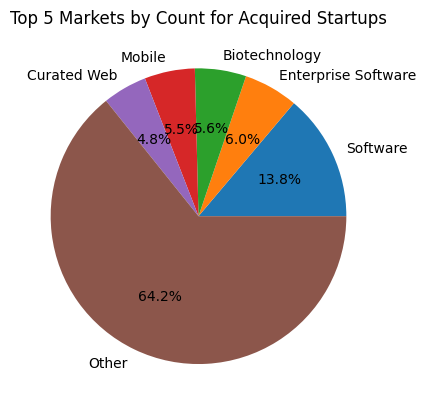

In [63]:
# Question 6: Create a pie chart showing the top 5 markets by count for acquired startups.

# Your firm wants to see the distribution of startups across markets, but only for those that have achieved "Acquired" status.

# The Catch: Group all other markets into a single category labeled "Other".

acquired = data_venture[data_venture["status"] == "acquired"]
market_counts = acquired["market"].value_counts()
other_count = market_counts.iloc[5:].sum()
market_counts = market_counts.iloc[:5]
market_counts["Other"] = other_count
market_counts

plt.pie(market_counts, labels=market_counts.index, autopct='%1.1f%%')
plt.title("Top 5 Markets by Count for Acquired Startups")
plt.show()



<Axes: xlabel='founded_year'>

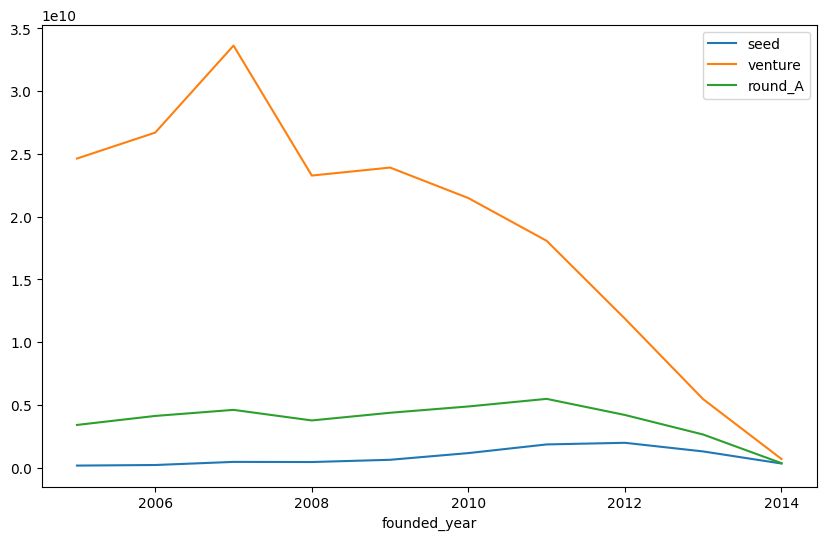

In [66]:
# Question 7: Create a line plot showing the annual sum of seed, venture, and round_A funding from the year 2005 to 2014.
# We need to track how different funding rounds have changed in popularity over time.


# Filter for the years 2005 to 2014

# Group by year and sum the funding rounds

# Create the line plot

selected_years = data_venture[(data_venture['founded_year'] > 2004) & (data_venture['founded_year'] < 2015)]
funding_types = ['seed', 'venture', 'round_A']
funding_sum = selected_years.groupby('founded_year')[funding_types].sum()
plot_line = funding_sum.plot(kind='line', figsize=(10, 6))
plot_line


## 🧬 Exercise 3: Unsupervised Learning (Clustering)

Not all startups are equal. VenturAI proposes to group them based on their *investment signatures*. By clustering companies with similar funding milestones, we can identify hidden archetypes of high-potential companies.

**Mission Requirements:**
*   Use **Hierarchical Clustering** to define distinct funding clusters.
*   Visualize the investment distance between startups using a **Dendrogram**.
*   Identify the common traits of startups that share a logic of investment.

VenturAI aims to identify distinct profiles of startups based on their funding behavior. You propose using unsupervised learning to group startups into clusters that share similar investment patterns, regardless of their market sector.

Your mission:

* Perform hierarchical clustering to identify distinct startup groups based on their funding histories.
* Analyze the similarities between companies in different clusters to understand common paths to success or failure.
* Visualize the relationships between these groups using a dendrogram to assist in defining the firm's investment strategy.

**note**: you can use `n_clusters = 4` and `Eucledian` distance with `Ward` linkage.


In [11]:
# Agglomerative Clustering for Venture Capital
# Question 8: Find the number of values in each clustering label
cluster = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
data_venture['cluster'] = cluster.fit_predict(data_venture[['funding_total_usd']])
data_venture['cluster'].value_counts()




In [12]:
# Dendrogram for Startup Investment Profiles


In [13]:
# Agglomerative Clustering for "Finance|FinTech" Startups


## 📈 Exercise 4: Supervised Learning — Impact of Momentum

A key question for our firm: **"Does the number of previous funding rounds accurately predict the final total funding received?"** Momentum is often a predictor of scale. You will test this using the simplest possible predictive model.

**Mission Goals:**
*   **Heatmap Discovery:** Visualize correlations between different funding stages.
*   **Single Regression:** Predict `funding_total_usd` using `funding_rounds` as a single feature.
*   **Error Metrics:** Quantify the model's reliability using R², MSE, and MAE.

One of the partners asks: "Does the number of funding rounds have a measurable impact on the total funding a startup receives?" You decide to test this relationship using a basic regression model.

**Your mission:**
* Plot a heatmap of correlations between numeric funding columns.
* Model `funding_total_usd` as a function of `funding_rounds` (with `test_size = 0.3`, `random_state = 123` and `shuffle=True`).
* Use `MinMaxScaler` and find the $R^2$, the MSE and the MAE.

In [14]:
# Question 9: Plot heatmap of correlations




In [15]:
# Seperate features and labels


In [16]:
# Split data into train and test sets



In [17]:
# Scale the data



In [18]:
# Create linear regression model and fit into the training data



In [19]:
# Question 10: Print out the R2, MSE and MAE score





## 🤖 Exercise 5: Multivariate Complexity

Relationships in the real world are rarely one-dimensional. To improve predictability, we must incorporate categorical indicators like sectoral demand and geographical advantages.

**Mission Goals:**
*   **Encoding:** Transform high-cardinality categorical data (`market` and `country_code`) into numeric inputs.
*   **Multivariate Modeling:** Train a model using all available indicators.
*   **Performance Comparison:** Compare accuracy against the simpler model to justify the inclusion of complex features.

Real-life success is rarely determined by a single factor. You now create a new model to include other variables like the market sector and the geographic region.

**Your mission:**
* Transform the `market` column using `LabelEncoder` and the `country_code` column using `One-Hot` encoding.
* Build a multivariate regression model using multiple features to predict total funding (with `test_size = 0.3`, `random_state = 123` and `shuffle=True`).
* Compare its performance with the previous simple regression model.

In [20]:
# Seperate features and labels, and transform the columns market and country_code






In [21]:
# Split data into train and test sets, create linear regression model and fit into the training data





In [22]:
# Question 11: Print out the R2, MSE and MAE score




# Part 2: Association Rules - Turn movies ratings into bussiness insights!

Lights, Camera, Data!

Are you a movie fan? I bet you are! Have you ever wondered how streaming platforms like Netflix seem to know exactly which movie you'll love next? You might have heard that they use recommendation algorithms and wondered how they work.

In this assignment, you'll explore how **association rules** can be used to develop a simple recommendation algorithm. The idea is simple: by analyzing which movies are frequently watched together, we can uncover patterns and use these insights to suggest movies based on a user's viewing history.

Now, let's dive in and make it happen!

## Exercise 1: Data Processing

We will use a subset of MoviesLens dataset, which consists of user ratings for a list of movies and information about the movies themselves (i.e., title and genres).

First, you need to load the ratings data from the URL below, and try to print out the size of the dataset, the number of users who provided ratings, and the number of movies that have been rated.

URL = "https://storage.googleapis.com/project_bia_unil/ratings.csv"

The `ratings` dataset contains four columns:

- `userID`: The ID of the user.
- `movieID`: The ID of the movie being rated.
- `rating`: The rating given by the user for the corresponding movie.
- `timestamp`: The timestamp when the rating was recorded.

In [23]:
# Print the first 5 rows of the dataframe



In [24]:
# Print the shape of the dataframe



In [25]:
# Print the number of ratings available



In [26]:
# Print the number of users who provided ratings


In [27]:
# Print the number of movies have been rated



Now, we need to transform the dataset into a matrix of size `n_users` × `n_movies`, where each row represents a user's ratings for all movies. If a user has not rated a movie, the rating will be 0.

To create this matrix, we will use the `pivot` function from pandas.

You can see that there are a lot of NaN values because each user rates only a subset of movies (those they have watched). We need to fill these NaN values with 0s.

In [28]:
# Replace NaN values with 0


Next, we don’t just want to identify movies that are frequently watched together—we want to focus on the ones that people actually enjoy. To do this, we'll consider a rating of 3 or higher as an indicator that a viewer liked the movie.

Therefore, we need to map ratings ≥ 3 to `True` (liked) and ratings below 3 to `False` (not liked).

Now, we are ready to apply the association rules!!

## Exercise 2: Association Rules



We will apply the **Apriori algorithm** to identify interesting association rules.

First, we need to find the frequent itemsets using the following configurations:

`min_support = 0.1`
`max_len = 2`

In [29]:
# Find the frequent itemsets



In [30]:
# Question 12: Find the number of itemsets



Now, we will mine the association rules from the frequent itemsets found above using `metric='lift'` and `min_threshold=1`.

In [31]:
# Find association rules



Now, let's map the movie IDs with their titles so we can identify them.

First, let's load the `movies` dataset from this URL: "https://storage.googleapis.com/project_bia_unil/movies.csv"

You will see that the `movies` dataset has 3 columns:
- `movieID`: The ID of the movie.
- `title`: The title of the movie.
- `genres`: The genres of the movie.

In the following cell, we provide the code to map movie IDs with their titles. We assume that you are using the variable `rules` to store the association rules. If you used a different variable name, please update the code accordingly.

In [32]:
# Map antecedents and consequents with movie names
# rules[rules["lift"] > 1].sort_values(by="lift", ascending=False)
# rules.head()

Now, we are ready to find out the most interesting association rules (i.e a pair of movies that are watched together) in term of the `lift` metric

In [33]:
# Question 13: Find the most interesting rule



In [34]:
# Question 14: Find the movie that is the most frequently watched together with "Beauty and the beast (1991)"




# Part 3: Binary Classification

You are working at a leading Tour & Travel Company, and there’s trouble on the horizon — some customers are slipping away, never to book again! Your job is to predict which customers are at risk of churning and help the company keep them engaged.

Using historical customer data, you’ll use binary classification algorithms to identify potential churners before they disappear.

First, you need to load the dataset from this URL: "https://storage.googleapis.com/project_bia_unil/travel.csv"

The dataset consists of following columns:
- `Age`: Age of customer.
- `FrequentFlyer`: Whether the customer takes frequent flights.
- `AnnualIncomeClass`: Class of the customer's annual income.
- `ServicesOpted`: Number of times services opted during recent years.
- `AccountSyncedToSocialMedia`: Whether company account of the user is synchronised to their social media.
- `BookedHotelOrNot`: Whether the customer books hotels using company services.
- `Target`: Whether the customer is a churner (1 for yes, 0 for no).

Try to print out the number of samples available in the dataset and types of each columns.

In [35]:
# Print the first 5 rows



In [36]:
# Print the number of samples in the dataset



In [37]:
# Print the column types



## Exercise 1: Preprocess


First, we want to convert the columns with an object data type to
a **categorical** one and visualize the correlation heatmap of the dataset's features.

In [38]:
# Question 15: Plot heatmap of correlations



Now, let's separate the dataset into features (X) and labels (y). Then, split the data into train and test sets using `train_test_split` function from Sklearn with `test_size=0.2`, `random_state=42`, and set `stratify=y` to preserve the label distribution in both sets.

In [39]:
# Seperate the dataset into features and labels



In [40]:
# Split into train and test sets



Before building any model, it's useful to establish a simple reference point. Imagine predicting the most frequent class for every single observation—no learning, just repetition. The accuracy you'd get from that naive approach is called the baseline accuracy. It’s the minimum benchmark any meaningful model should aim to outperform.

In [41]:
# Question 16: Calculate baseline accuracy



Now, let's standardize the features using `StandardScaler` from Sklearn.

In [42]:
# Standardise features



## Exercise 2: Logistic regression

First, try use logistic regression for use our data. Use LogisticRegression with the following setting:
`penalty='l2', solver='lbfgs', max_iter=1000, random_state=30`

In [43]:
# Logistic Regression



In [44]:
# Question 17: Find the test accuracy



Next, train a logistic regression classifier with cross-validation. Use 5 folds and 9 values in the logscale between $10^{-4}$ and $10^4$ for the regularizer parameter. For the rest of the arguments, we use the same values as we used for the logistic regression with no cross validation.

__Important:__ Set the following values for the arguments:
`
solver='lbfgs', max_iter=1000, random_state=42, cv=4, Cs=*9*
`

In [45]:
# Train a logistic regression classifier with cross-validation

# error in the question cv = 4 or 5 ?
# no problem because bothe give the same result

In [46]:
# Question 18: Find the value of the test accuracy


## Exercise 3: KNN classifier

Use the KNeighborClassifier from sklearn using the following setting:
`n_neighbors=7, p=2, weights='uniform', algorithm="kd_tree"`

In [47]:
# KNeighborClassifier

#y_pred_knn = knn_classifier.predict(X_test_scaled)


Use `GridSearchCV` to find the best hyper-parameters for your KNN model. Use values between 1 and 10 for `n_neighbors` argument and use either 'uniform' or 'distance' for the `weights` argument. Use a 5-fold cross validation. This translate to the following values for the arguments of the `GridSearchCV`:
```
param_grid={"n_neighbors": range(1, 11), "weights":["uniform", "distance"]}, cv=5
```

In [48]:
# Question 19: Find the accuracy of the best KNN model




In [49]:
# Question 20: Find the 'n_neighbors' and 'weights' values for the best KNN model




## Exercise 4: Decision Tree

Train a Decision Tree classifier on the training data. Use the following values for the arguments of the decision tree:
```
criterion="gini", max_depth=3, random_state=30
```

In [50]:
# Decision Tree


#y_pred_dt = dt_classifier.predict(X_test_scaled)


Use `GridSearchCV` to find the best hyper-parameters for your decision tree model. Use values between 1 and 7 for `max_depth` argument and use either 'gini' or 'entropy' for the `criterion` argument. Use a 5-fold cross validation. This translate to the following values for the arguments of the `GridSearchCV`:
```
param_grid={"max_depth": range(1, 8), "criterion":["gini", "entropy"]}, cv=5
```

In [51]:
# Question 21: Find the accuracy of the best decision tree model




In [52]:
# Question 22: Find the 'criterion' and 'max_depth' values for the best decision tree model




The company places a strong emphasis on keeping its customers and has solid resources dedicated to retention. In such a case, choosing the right evaluation metric becomes crucial. The answer lies in understanding what matters most in this context.


Question 23: Find the best metric for the company

> The best metric for the Company is Recall beacuse we want to know how well our model identifies actual churners (true positives).

In [53]:
# Question 23: Find the model that gives the best result using the metric above

